In [2]:
# initialisation 

## vérifier à la fin si on utilise bien tout ces import ##

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import seaborn as sns

df = pd.read_csv("../output/df_modele_musees.csv")

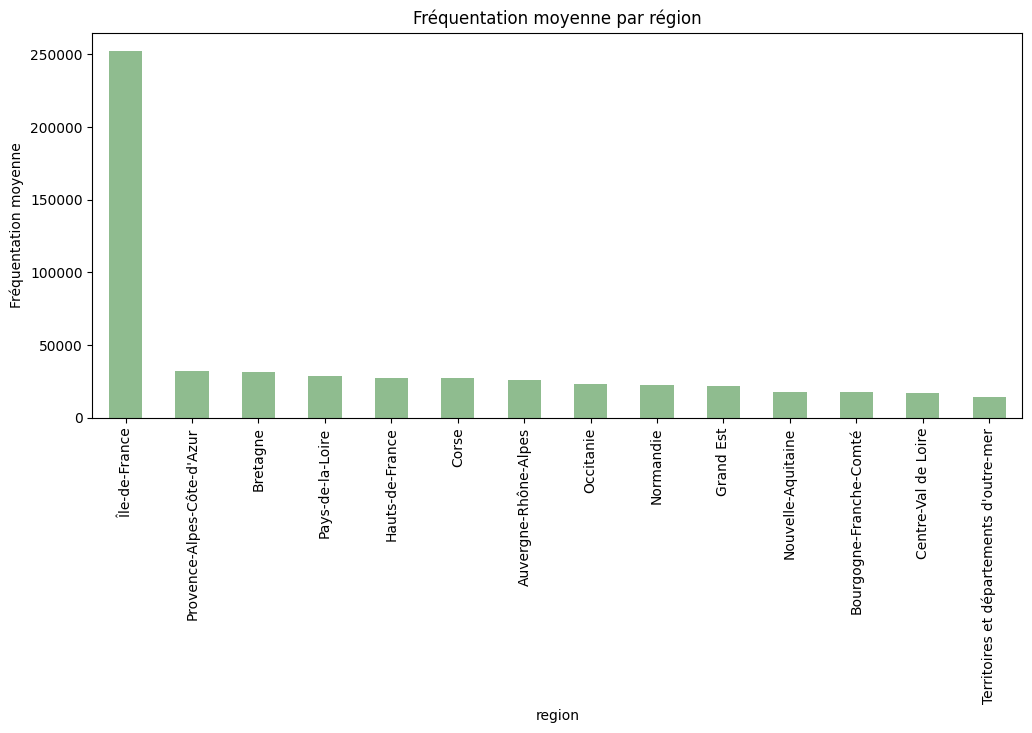

In [3]:
# FRÉQUENTATION MOYENNE PAR RÉGION

df_reg = (
    df.groupby("region")["total"]
      .mean()
      .sort_values(ascending=False)
)

df_reg.plot(kind="bar", figsize=(12,5), color="darkseagreen")
plt.title("Fréquentation moyenne par région")
plt.ylabel("Fréquentation moyenne")
plt.show()

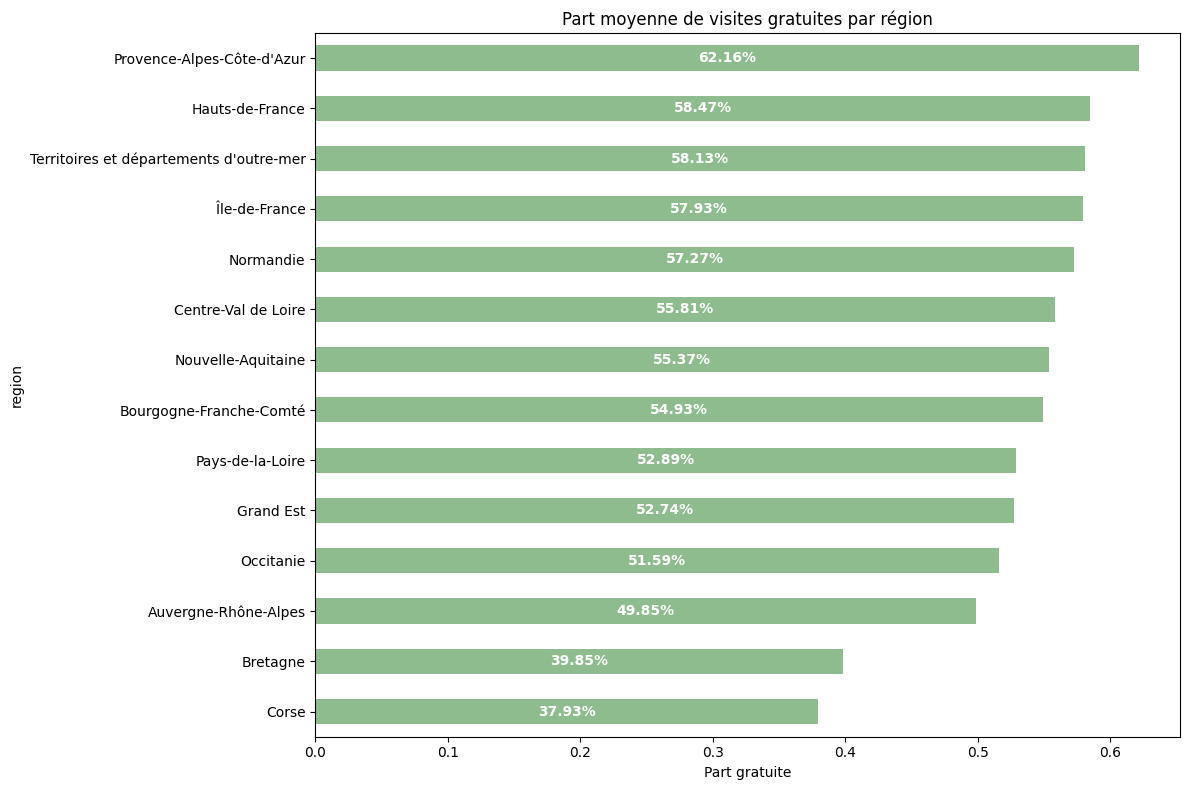

In [ ]:
# PART MOYENNE D'ENTRÉES GRATUITES PAR RÉGION 

df_gratuit_reg = (
    df.groupby("region")["part_gratuit"]
        .mean()
        .sort_values(ascending=True)
)

ax = df_gratuit_reg.plot(figsize=(12,8), kind="barh", color = "darkseagreen")
plt.title("Part moyenne de visites gratuites par région")
plt.xlabel("Part gratuite")

# Ajout des valeurs sur les barres
for i, value in enumerate(df_gratuit_reg):
    ax.text(value/2, i, f"{value*100:.2f}%", va="center", ha="center", color="white", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

In [ ]:
# TOP 10 DES MUSÉES LES PLUS VISITÉS EN FRANCE

top_musees = (
    df.groupby("nom_officiel")
      .agg(
          total_visites=("total", "sum"),
          region=("region", "first"),                           
          domaine=("domaine_thematique", "first")
      )
      .sort_values("total_visites", ascending=False)
      .head(10)
      .reset_index()
)

top_musees.columns = [
    "Nom du musée",
    "Total des visites",
    "Région",
    "Domaine thématique"
]

top_musees

,Nom du musée,Total des visites,Région,Domaine thématique
0,musée du Louvre,74214827.0,Île-de-France,Archéologie;Arts décoratifs;Beaux-arts;Histoir...
1,musée national des châteaux de Versailles et d...,65671728.0,Île-de-France,Arts décoratifs;Beaux-Arts;Histoire
2,musée d'Orsay,29090594.0,Île-de-France,Arts décoratifs;Beaux-Arts;Histoire
3,musée national d'art moderne (centre national ...,29030390.0,Île-de-France,Art moderne et contemporain;Photographie;Techn...
4,musée des beaux-arts,22617440.0,Grand Est,Beaux-arts
5,muséum d'histoire naturelle,11473692.0,Bourgogne-Franche-Comté,Sciences de la nature;Technique et industrie;E...
6,musée de l'armée,10874249.0,Île-de-France,Histoire;Technique et industrie;Militaria;Ethn...
7,musée du Quai Branly - Jacques Chirac,10152136.0,Île-de-France,Archéologie;Art moderne et contemporain;Histoi...
8,"Petit Palais, musée des beaux-arts de la ville...",9173637.0,Île-de-France,Arts décoratifs;Art moderne et contemporain;Be...
9,musée de l'Orangerie des Tuileries,8188706.0,Île-de-France,Art moderne et contemporain
